In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("Titanic-Dataset.csv",usecols=['Age', 'Fare', 'Survived'])

In [3]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_12224\694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

C:\Users\admin\AppData\Local\Temp\ipykernel_12224\1389256493.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


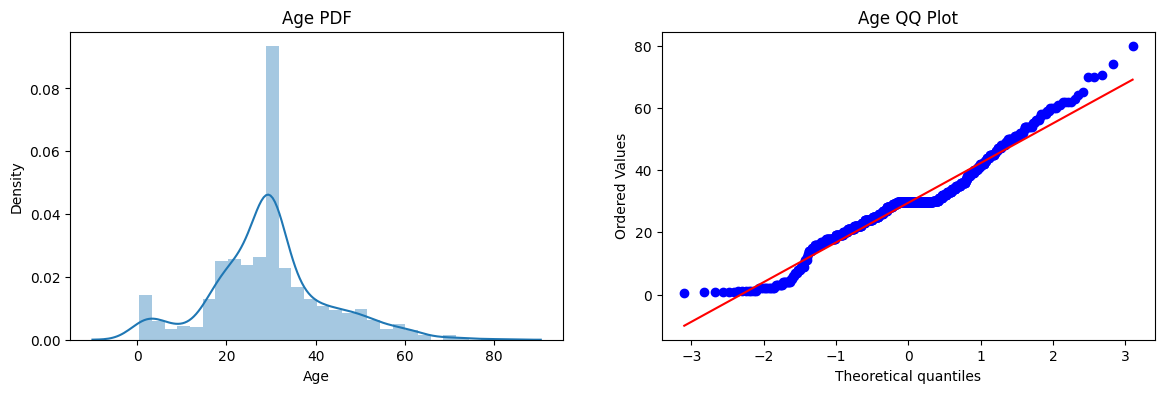

In [7]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title("Age PDF")

plt.subplot(122)
stats.probplot(X_train['Age'],dist="norm", plot=plt)
plt.title("Age QQ Plot")

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_12224\547791311.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


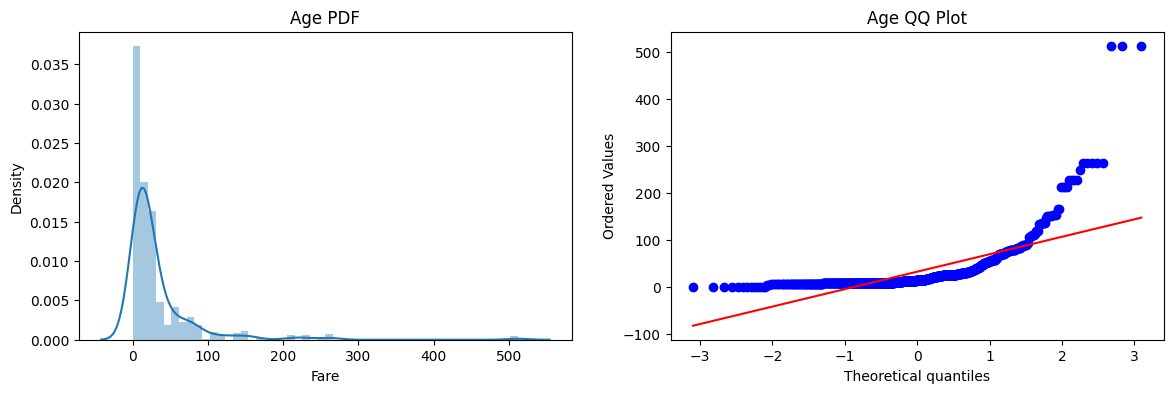

In [8]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title("Age PDF")

plt.subplot(122)
stats.probplot(X_train['Fare'],dist="norm", plot=plt)
plt.title("Age QQ Plot")

plt.show()

In [9]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [10]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6815642458100558


In [11]:
trf = FunctionTransformer(func=np.log1p)

In [12]:
X_train_Transformed = trf.transform(X_train)
X_test_Transformed = trf.transform(X_test)

In [14]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_Transformed,y_train)
clf2.fit(X_train_Transformed,y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.7374301675977654
Accuracy DT 0.5921787709497207


In [16]:
X_Transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_Transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_Transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6588639200998752


((array([-3.09833772e+00, -2.82529557e+00, -2.67239243e+00, -2.56428702e+00,
         -2.47977990e+00, -2.40996845e+00, -2.35023723e+00, -2.29787334e+00,
         -2.25114194e+00, -2.20886405e+00, -2.17020067e+00, -2.13453273e+00,
         -2.10138998e+00, -2.07040647e+00, -2.04129166e+00, -2.01381086e+00,
         -1.98777170e+00, -1.96301446e+00, -1.93940499e+00, -1.91682952e+00,
         -1.89519069e+00, -1.87440451e+00, -1.85439799e+00, -1.83510731e+00,
         -1.81647630e+00, -1.79845528e+00, -1.78100007e+00, -1.76407122e+00,
         -1.74763334e+00, -1.73165455e+00, -1.71610603e+00, -1.70096166e+00,
         -1.68619765e+00, -1.67179230e+00, -1.65772574e+00, -1.64397975e+00,
         -1.63053756e+00, -1.61738369e+00, -1.60450386e+00, -1.59188484e+00,
         -1.57951433e+00, -1.56738092e+00, -1.55547396e+00, -1.54378354e+00,
         -1.53230037e+00, -1.52101577e+00, -1.50992160e+00, -1.49901023e+00,
         -1.48827446e+00, -1.47770753e+00, -1.46730308e+00, -1.45705508e+00,

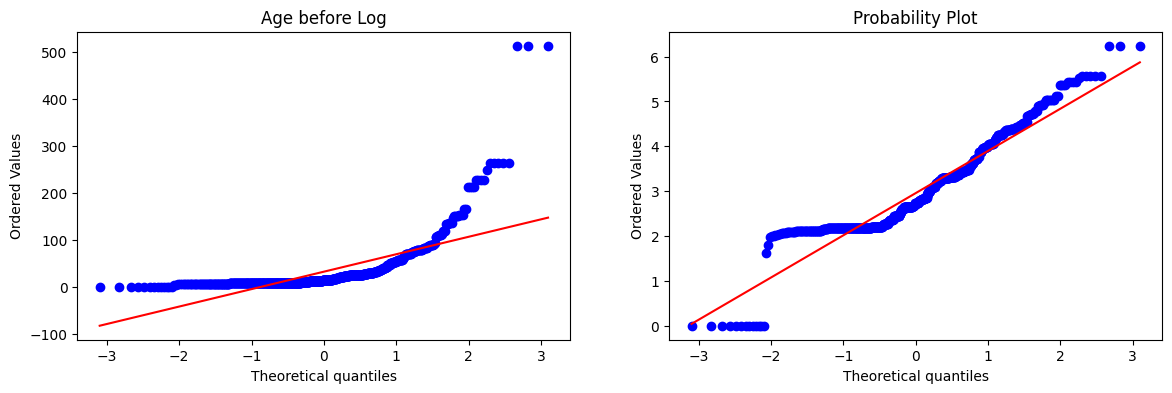

In [17]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'],dist="norm",plot=plt)
plt.title("Age before Log")

plt.subplot(122)
stats.probplot(X_train_Transformed['Fare'],dist="norm",plot=plt)

((array([-3.09833772e+00, -2.82529557e+00, -2.67239243e+00, -2.56428702e+00,
         -2.47977990e+00, -2.40996845e+00, -2.35023723e+00, -2.29787334e+00,
         -2.25114194e+00, -2.20886405e+00, -2.17020067e+00, -2.13453273e+00,
         -2.10138998e+00, -2.07040647e+00, -2.04129166e+00, -2.01381086e+00,
         -1.98777170e+00, -1.96301446e+00, -1.93940499e+00, -1.91682952e+00,
         -1.89519069e+00, -1.87440451e+00, -1.85439799e+00, -1.83510731e+00,
         -1.81647630e+00, -1.79845528e+00, -1.78100007e+00, -1.76407122e+00,
         -1.74763334e+00, -1.73165455e+00, -1.71610603e+00, -1.70096166e+00,
         -1.68619765e+00, -1.67179230e+00, -1.65772574e+00, -1.64397975e+00,
         -1.63053756e+00, -1.61738369e+00, -1.60450386e+00, -1.59188484e+00,
         -1.57951433e+00, -1.56738092e+00, -1.55547396e+00, -1.54378354e+00,
         -1.53230037e+00, -1.52101577e+00, -1.50992160e+00, -1.49901023e+00,
         -1.48827446e+00, -1.47770753e+00, -1.46730308e+00, -1.45705508e+00,

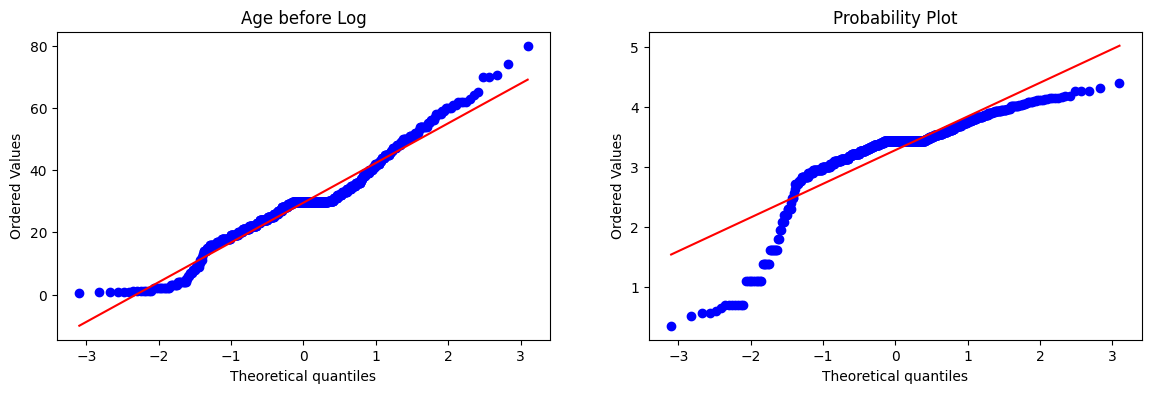

In [18]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'],dist="norm",plot=plt)
plt.title("Age before Log")

plt.subplot(122)
stats.probplot(X_train_Transformed['Age'],dist="norm",plot=plt)

In [19]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_Transformed = trf2.fit_transform(X_train)
X_test_Transformed = trf2.fit_transform(X_test)

In [21]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_Transformed,y_train)
clf2.fit(X_train_Transformed,y_train)

y_pred = clf.predict(X_test_Transformed)
y_pred2 = clf2.predict(X_test_Transformed)

print(" Accuracy LR",accuracy_score(y_test,y_pred))
print(" Accuracy DT",accuracy_score(y_test,y_pred2))

 Accuracy LR 0.6703910614525139
 Accuracy DT 0.664804469273743


In [22]:
X_Transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_Transformed2,y,scoring='accuracy',cv=10)))
print("LR",np.mean(cross_val_score(clf2,X_Transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
LR 0.6644444444444445


In [28]:
def apply_transformer(transformer):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transformer),['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print('Accuracy',np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'],dist="norm",plot=plt)
    plt.title("Fare Before Transform")

    plt.subplot(122)
    stats.probplot(X_trans[:,0],dist="norm",plot=plt)
    plt.title("Fare After Transform")

    plt.show()

    


Accuracy 0.6577403245942571


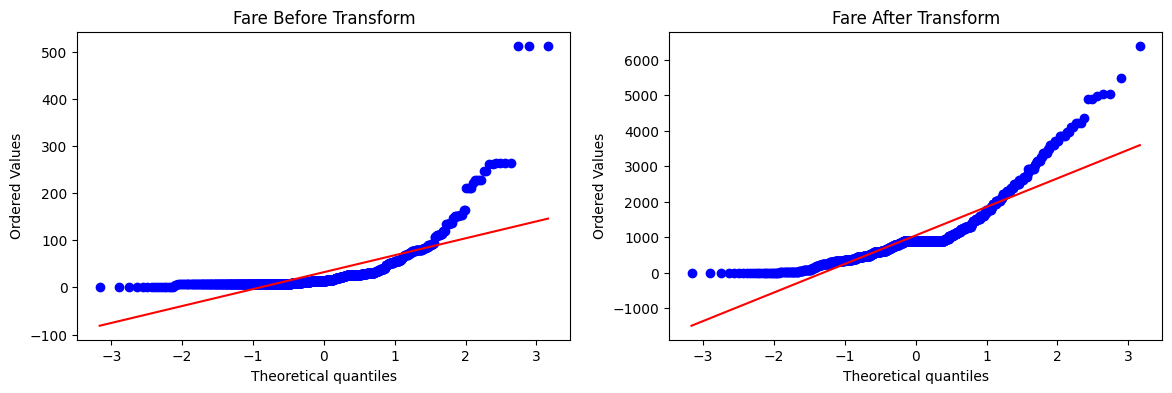

In [30]:
apply_transformer(lambda x: X**2)

Accuracy 0.6251685393258427


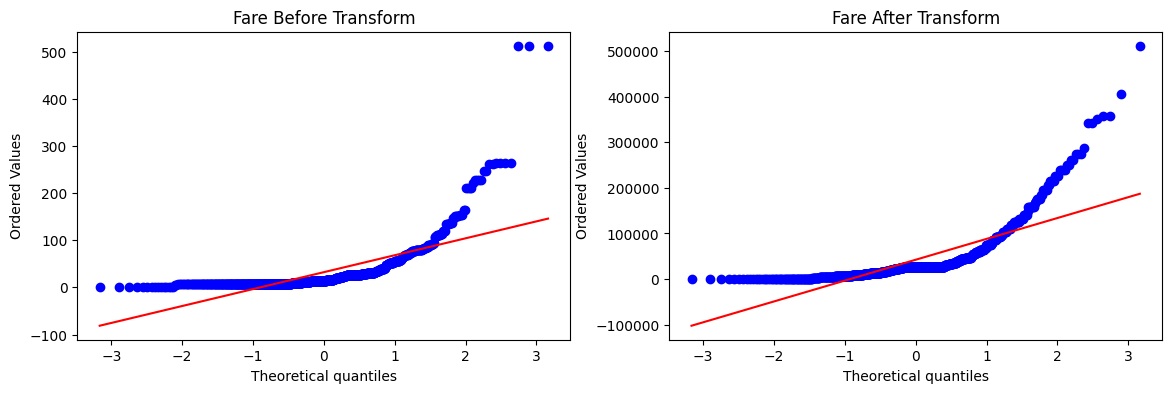

In [31]:
apply_transformer(lambda x: X**3)

Accuracy 0.6589013732833957


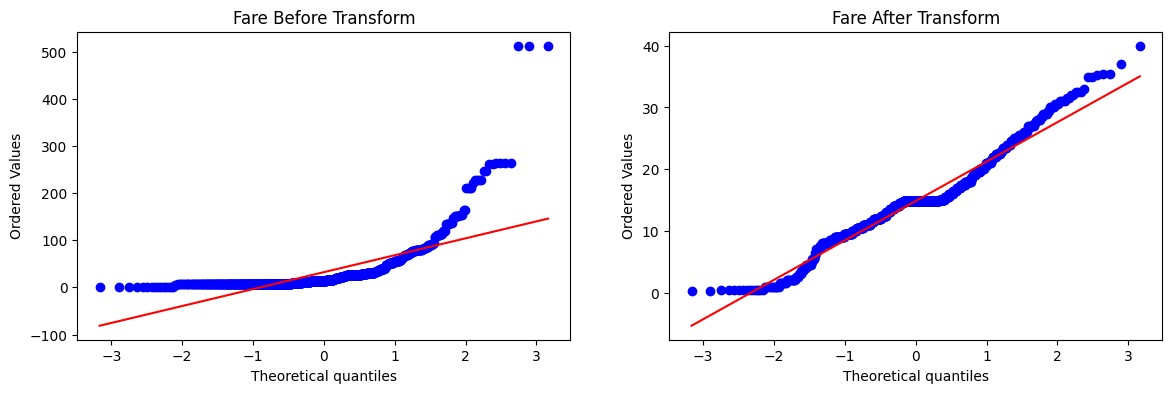

In [32]:
apply_transformer(lambda x: X**1/2)

Accuracy 0.61729088639201


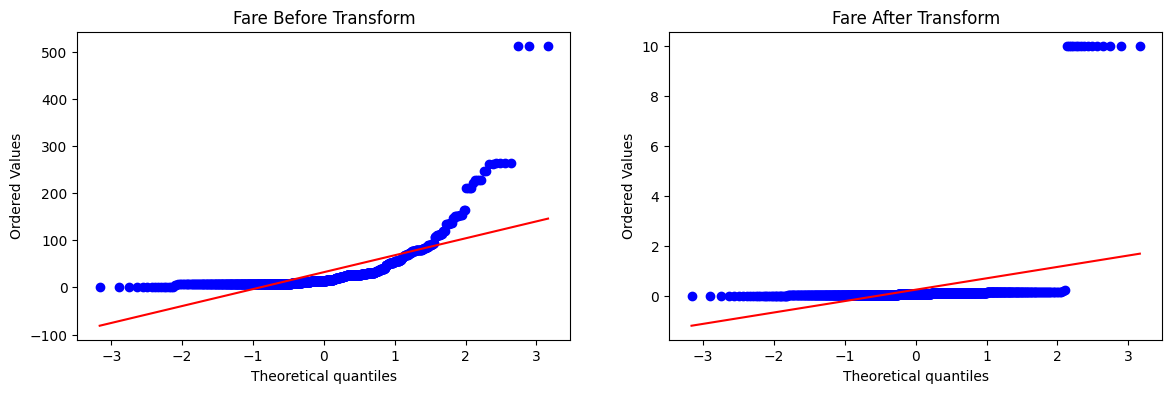

In [36]:
apply_transformer(lambda x: 1/(x+0.1))